<a href="https://colab.research.google.com/github/allegiova/TinyML/blob/main/model_training_assing2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import os

# Data Visualization

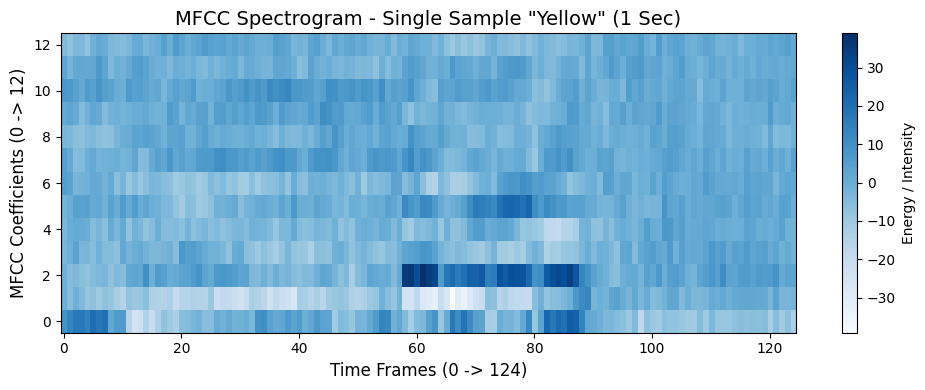

In [22]:
# 1. Extract only the first 1-second sample (125 frames)
single_sample_frames = []

with open('yellow.csv', 'r') as file:
    for line in file:
        values = line.strip().split('\t')

        # Check if the row has exactly 13 columns (ignore text like "GO!")
        if len(values) == 13:
            try:
                # Convert string values to floats
                single_sample_frames.append([float(x) for x in values])
            except ValueError:
                continue # Skip the row if it contains non-numeric characters

        # Stop reading as soon as we reach 125 frames (exactly 1 second of audio)
        if len(single_sample_frames) == 125:
            break

# Convert the list into a NumPy array
sample_data = np.array(single_sample_frames)

# Compute the transpose for plotting: from (125 rows x 13 cols) to (13 rows x 125 cols)
# This places time on the X-axis and MFCC features on the Y-axis
mfcc_image = sample_data.T

# 2. Create the plot (Spectrogram / Heatmap)
plt.figure(figsize=(10, 4))
plt.imshow(mfcc_image, cmap='Blues', aspect='auto', origin='lower')

# Add labels and details to the chart
plt.title('MFCC Spectrogram - Single Sample "Yellow" (1 Sec)', fontsize=14)
plt.xlabel('Time Frames (0 -> 124)', fontsize=12)
plt.ylabel('MFCC Coefficients (0 -> 12)', fontsize=12)
plt.colorbar(label='Energy / Intensity')

# Optimize layout and render the plot
plt.tight_layout()
plt.show()

#Dataset Creation

In [23]:
# ==========================================
# 1. DATASET CONFIGURATION
# ==========================================
# Neural networks cannot read text (like "blue" or "green").
# They only understand math. Here we map each spoken word to a unique integer (Label).
CLASSES = {
    "blue": 0,
    "green": 1,
    "red": 2,
    "yellow": 3
}

# Each valid audio sample lasts 1 second, which Arduino converts into exactly 125 frames.
FRAMES_PER_SAMPLE = 125
# Each frame contains exactly 13 MFCC features (Mel Frequency Cepstral Coefficients).
NUM_COEFFS = 13

# ==========================================
# 2. DATA EXTRACTION FUNCTION
# ==========================================
def load_dataset_from_csv(class_dict):
    # X will store the audio features (a big list of 125x13 matrices)
    X = []
    # y will store the correct answers/labels (a list of integers: 0, 1, 2, or 3)
    y = []

    # Loop through each color and its corresponding numerical label in the dictionary
    for color_name, label in class_dict.items():
        filename = f"{color_name}.csv"
        current_sample = [] # Temporary list to build a single 125-frame matrix
        samples_found = 0   # Counter to track how many 1-second samples we find in this file

        # Open the CSV file for the current color
        with open(filename, 'r') as file:
            for line in file:
                # Remove hidden newline characters and split the row by tabs
                values = line.strip().split('\t')

                # Verify that the row actually contains exactly 13 elements
                if len(values) == NUM_COEFFS:
                    try:
                        # Attempt to convert the 13 string values into decimal numbers (floats)
                        numeric_row = [float(val) for val in values]
                        current_sample.append(numeric_row)
                    except ValueError:
                        # If conversion fails (e.g., the row contains Arduino text like "GO!"),
                        # we simply ignore the row and continue to the next one.
                        pass

                # Once our temporary list accumulates exactly 125 valid frames...
                if len(current_sample) == FRAMES_PER_SAMPLE:
                    # ...we have successfully captured 1 full second of audio!
                    X.append(current_sample)  # Add the 125x13 matrix to our features dataset
                    y.append(label)           # Add the corresponding label to our target dataset
                    samples_found += 1        # Increment our success counter

                    # Clear the temporary list so it is empty and ready to capture the NEXT sample
                    current_sample = []

        # Print a summary of how many complete samples were successfully extracted from the file
        print(f"Extracted {samples_found} samples from {filename}")

    # Machine Learning libraries (like TensorFlow/Keras) require data in NumPy arrays,
    # not standard Python lists. We convert them before returning.
    return np.array(X), np.array(y)

# ==========================================
# 3. BUILD X AND y
# ==========================================
# Execute the function and store the resulting NumPy arrays in our global variables
X_data, y_data = load_dataset_from_csv(CLASSES)

print("\n--- DATASET SUMMARY ---")
# X is a 3D tensor: (Number of Audio Samples, 125 Time Frames, 13 MFCC Features)
print(f"Shape of X (Features): {X_data.shape} -> (Total Samples, Time Frames, MFCCs)")
# y is a 1D vector: (Number of Audio Samples,) containing just the numerical labels
print(f"Shape of y (Labels):   {y_data.shape} -> (Total Samples,)")

Extracted 26 samples from blue.csv
Extracted 26 samples from green.csv
Extracted 29 samples from red.csv
Extracted 27 samples from yellow.csv

--- DATASET SUMMARY ---
Shape of X (Features): (108, 125, 13) -> (Total Samples, Time Frames, MFCCs)
Shape of y (Labels):   (108,) -> (Total Samples,)


# Create and Train the Network

In [24]:
# ==========================================
# STEP 1: SPLIT THE DATASET
# ==========================================
# We must divide our data into a "Training Set" (to teach the network)
# and a "Test Set" (to evaluate it on unseen data).
# test_size=0.2 means 20% of our 52 samples (about 10 samples) are kept hidden for the final test.
# random_state=42 ensures the random shuffling is the same every time we run the code.

X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_data,
    test_size=0.2,
    random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

# ==========================================
# STEP 2: BUILD THE CNN 1D ARCHITECTURE
# ==========================================
# We follow the exact architecture described in Professor Yildirim's slides for Keyword Spotting.

model = models.Sequential([
    # 1. INPUT LAYER:
    # Tells the network the shape of exactly one sample: a matrix of 125 rows (time) and 13 columns (MFCCs).
    layers.Input(shape=(FRAMES_PER_SAMPLE, NUM_COEFFS)),

    # 2. FIRST CONVOLUTIONAL BLOCK:
    # Uses a 'sliding window' (kernel_size=3) to scan the 125 frames looking for basic audio patterns.
    # It applies 16 different filters. 'relu' activation helps it learn complex, non-linear sounds.
    layers.Conv1D(filters=16, kernel_size=3, activation='relu', padding='same'),
    # MaxPooling compresses the data by taking the most important feature every 2 frames, saving memory.
    layers.MaxPooling1D(pool_size=2),

    # 3. SECOND CONVOLUTIONAL BLOCK:
    # Scans the compressed data again with 32 filters to find more complex, higher-level patterns (like full phonemes).
    layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling1D(pool_size=2),

    # 4. FLATTEN:
    # The data is still a 2D matrix. We must "flatten" it into a single, long 1D array of numbers
    # so the final classification layer can read it.
    layers.Flatten(),

    # 5. DROPOUT:
    # Randomly turns off 25% (0.25) of the neurons during training.
    # This prevents the network from memorizing the specific voices, forcing it to learn general patterns (prevents Overfitting).
    layers.Dropout(0.25),

    # 6. OUTPUT LAYER:
    # A Dense layer with exactly 4 neurons (one for Blue, Green, Red, Yellow).
    # The 'softmax' activation converts the output into percentages (e.g., "I am 90% sure this is Yellow").
    layers.Dense(len(CLASSES), activation='softmax')
])

# ==========================================
# STEP 3: COMPILE THE MODEL
# ==========================================
# We define HOW the network will learn from its mistakes.
model.compile(
    optimizer='adam',                                # The standard and most efficient learning algorithm
    loss='sparse_categorical_crossentropy',          # The mathematical function that calculates "how wrong" the network's guess was
    metrics=['accuracy']                             # We want to track the percentage of correct predictions
)

# Print a visual summary of the architecture and how many parameters (weights) it needs to learn.
model.summary()

# ==========================================
# STEP 4: TRAIN THE MODEL
# ==========================================
print("\n--- STARTING TRAINING ---")
# epochs=30: The network will read the entire Training Set 30 times.
# batch_size=8: It will process 8 audio samples at a time before updating its weights.
history = model.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=16,
    validation_data=(X_test, y_test) # After each epoch, it tests itself on the hidden Test Set
)

# ==========================================
# STEP 5: FINAL EVALUATION
# ==========================================
# We do one final official check on the test data.
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n--- FINAL RESULTS ---")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Training samples: 86
Testing samples: 22


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 125, 16)        │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 62, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 62, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 31, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 992)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 992)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │         3,972 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,180 (24.14 KB)

 Trainable params: 6,180 (24.14 KB)

 Non-trainable params: 0 (0.00 B)


--- STARTING TRAINING ---
Epoch 1/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.2442 - loss: 3.7466 - val_accuracy: 0.2273 - val_loss: 3.0026
Epoch 2/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3488 - loss: 2.7735 - val_accuracy: 0.5455 - val_loss: 1.8173
Epoch 3/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5349 - loss: 1.6095 - val_accuracy: 0.4091 - val_loss: 1.9408
Epoch 4/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5930 - loss: 1.3724 - val_accuracy: 0.3636 - val_loss: 1.8154
Epoch 5/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7442 - loss: 0.8714 - val_accuracy: 0.4091 - val_loss: 1.8823
Epoch 6/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8023 - loss: 0.4899 - val_accuracy: 0.4545 - val_loss: 1.4168
Epoch 7/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7791 - loss: 0.5998 - val_accuracy: 0.4091 - val_loss: 1.5828
Epoch 8/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7791 - loss: 0.5223 - val_a

# Make the .h file


In [25]:
# ==========================================
# 1. CONVERT THE MODEL TO TFLITE FORMAT
# ==========================================
# We use the TFLiteConverter to translate our Keras model into a micro-model
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Perform the actual conversion
tflite_model = converter.convert()

# Save the binary .tflite file to the current environment
tflite_filename = 'kws_model.tflite'
with open(tflite_filename, 'wb') as f:
    f.write(tflite_model)

print(f"Successfully saved binary file: {tflite_filename}")

# ==========================================
# 2. CONVERT TFLITE TO C++ HEADER FILE (.h)
# ==========================================
# Arduino cannot read a .tflite file directly.
# We must convert the binary data into a C-style array of bytes (hexadecimal).

# We use pure Python to generate the .h file to avoid issues with missing 'xxd' commands
hex_array = ', '.join([f'0x{b:02x}' for b in tflite_model])

# Write the C++ code into the header file
h_filename = 'kws_model.h'
with open(h_filename, 'w') as f:
    f.write('// Auto-generated TFLite model for Arduino Keyword Spotting\n')
    f.write('const unsigned char model[] = {\n')
    f.write(f'  {hex_array}\n')
    f.write('};\n\n')
    f.write(f'const unsigned int model_len = {len(tflite_model)};\n')

# ==========================================
# 3. VERIFY AND DOWNLOAD
# ==========================================
model_h_size = os.path.getsize(h_filename)
print(f"Header file '{h_filename}' generated successfully!")
print(f"File size: {model_h_size:,} bytes.")
print("\nIf you are using Google Colab, you can download it from the left panel (Files icon).")

Saved artifact at '/tmp/tmprl57j8z4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 125, 13), dtype=tf.float32, name='keras_tensor_48')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  134514107280528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134514107285136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134514090154064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134513581527248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134513581523024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134513581528208: TensorSpec(shape=(), dtype=tf.resource, name=None)
Successfully saved binary file: kws_model.tflite
Header file 'kws_model.h' generated successfully!
File size: 183,399 bytes.

If you are using Google Colab, you can download it from the left panel (Files icon).
